# Sentiment Analysis (Dashboard Section 5)

We classify sentiment (positive/negative/neutral) across our documents
using a multilingual model, then group results by category and date.

Model: cardiffnlp/twitter-xlm-roberta-base-sentiment

In [1]:
import json
import os
import chromadb
from transformers import pipeline
from dotenv import load_dotenv

load_dotenv("../.env")

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    token=os.getenv("HF_TOKEN")
)

print("Sentiment model loaded")

/Users/namratabhoyar/Downloads/SRH_Master/NLP/lufthansa_intelligence/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 30842.73it/s]


Sentiment model loaded


In [2]:
# Quick sanity check: test the model on clear example sentences
examples = [
    "Lufthansa increases profits significantly this quarter",
    "Lufthansa flight delays disappoint many passengers",
    "Lufthansa announces new flight schedule for next year"
]

for text in examples:
    result = sentiment_model(text)[0]
    print(f"{text}\n  → {result['label']} ({result['score']:.2f})\n")

Lufthansa increases profits significantly this quarter
  → positive (0.78)

Lufthansa flight delays disappoint many passengers
  → negative (0.91)

Lufthansa announces new flight schedule for next year
  → neutral (0.55)



## Step 1: Load Documents from ChromaDB


In [3]:
chroma_client = chromadb.PersistentClient(path="../storage/chromadb")
collection = chroma_client.get_collection("lufthansa_intelligence")
data = collection.get()

def get_year_month(date_str):
    # Already clean format: "2026-06-16"
    if date_str[4:5] == "-":
        return date_str[:7]
    # RSS format: "Thu, 04 Jul 2024 09:15:00 GMT"
    parts = date_str.split()
    if len(parts) >= 4:
        months = {"Jan":"01","Feb":"02","Mar":"03","Apr":"04","May":"05","Jun":"06",
                  "Jul":"07","Aug":"08","Sep":"09","Oct":"10","Nov":"11","Dec":"12"}
        month_num = months.get(parts[2], "01")
        return f"{parts[3]}-{month_num}"
    return "unknown"

documents = []
for i in range(len(data["ids"])):
    documents.append({
    "title": data["metadatas"][i]["title"],
    "text": data["documents"][i],
    "category": data["metadatas"][i]["category"],
    "date": get_year_month(data["metadatas"][i]["date"]),
    "source": data["metadatas"][i]["source"]
})

print(f"Loaded {len(documents)} documents")
print(f"Sample dates: {[d['date'] for d in documents[:5]]}")

Loaded 427 documents
Sample dates: ['2026-06', '2026-06', '2026-06', '2026-06', '2026-06']


## Step 2: Run Sentiment Analysis 


In [4]:
for doc in documents:
    result = sentiment_model(doc["text"][:500])[0]
    doc["sentiment"] = result["label"]

print("Sentiment analysis done")

Sentiment analysis done


## Step 3: Group Sentiment by Category


In [5]:
def count_sentiments(doc_list):
    counts = {"positive": 0, "negative": 0, "neutral": 0}
    for d in doc_list:
        counts[d["sentiment"]] += 1
    return counts

news_sentiment = count_sentiments([d for d in documents if d["category"] in ["news", "market"]])
public_sentiment = count_sentiments([d for d in documents if d["category"] == "community"])

print("News sentiment   :", news_sentiment)
print("Public sentiment :", public_sentiment)

News sentiment   : {'positive': 58, 'negative': 41, 'neutral': 213}
Public sentiment : {'positive': 7, 'negative': 16, 'neutral': 20}


## Step 4: Sentiment Trends by Date

We group sentiment by date to see how it changes over time.

In [6]:
# Only use documents with real publish dates (RSS), not DDGS/Wikipedia fallback dates
dated_documents = [
    doc for doc in documents
    if doc["source"] in ["Google News", "Google News Strategy", "Google News Finance", "Reddit Community"]
]

trends = {}
for doc in dated_documents:
    date = doc["date"]
    trends.setdefault(date, {"positive": 0, "negative": 0, "neutral": 0})
    trends[date][doc["sentiment"]] += 1

print(f"Using {len(dated_documents)} documents with genuine publish dates")
print(f"Trends across {len(trends)} months")
for month in sorted(trends.keys()):
    print(f"  {month}: {trends[month]}")

Using 260 documents with genuine publish dates
Trends across 36 months
  2007-10: {'positive': 0, 'negative': 0, 'neutral': 1}
  2015-12: {'positive': 1, 'negative': 0, 'neutral': 0}
  2017-03: {'positive': 1, 'negative': 0, 'neutral': 1}
  2017-04: {'positive': 1, 'negative': 1, 'neutral': 0}
  2017-11: {'positive': 1, 'negative': 0, 'neutral': 0}
  2018-10: {'positive': 0, 'negative': 1, 'neutral': 0}
  2019-11: {'positive': 0, 'negative': 1, 'neutral': 1}
  2020-08: {'positive': 0, 'negative': 1, 'neutral': 0}
  2021-03: {'positive': 0, 'negative': 0, 'neutral': 3}
  2022-05: {'positive': 0, 'negative': 1, 'neutral': 0}
  2022-10: {'positive': 0, 'negative': 0, 'neutral': 1}
  2023-03: {'positive': 2, 'negative': 1, 'neutral': 1}
  2023-07: {'positive': 0, 'negative': 0, 'neutral': 1}
  2023-08: {'positive': 0, 'negative': 0, 'neutral': 1}
  2023-11: {'positive': 0, 'negative': 0, 'neutral': 2}
  2024-03: {'positive': 3, 'negative': 0, 'neutral': 1}
  2024-05: {'positive': 0, 'negat

## Step 5: Save Sentiment Results


In [7]:
output = {
    "news_sentiment": news_sentiment,
    "public_sentiment": public_sentiment,
    "sentiment_trends": trends
}

with open("../data/sentiment_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print("Saved to data/sentiment_results.json")

Saved to data/sentiment_results.json


## Step 6: Visualize Sentiment Distribution

A quick visual check of our sentiment results before building the full dashboard.

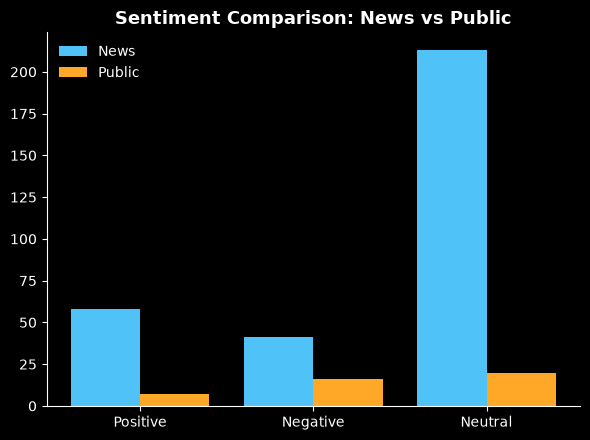

In [8]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

labels = ["Positive", "Negative", "Neutral"]
news_vals = [news_sentiment[l.lower()] for l in labels]
public_vals = [public_sentiment[l.lower()] for l in labels]

fig, ax = plt.subplots(figsize=(6, 4.5))
x = range(len(labels))
ax.bar([i - 0.2 for i in x], news_vals, width=0.4, label="News", color="#4FC3F7")
ax.bar([i + 0.2 for i in x], public_vals, width=0.4, label="Public", color="#FFA726")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.legend(frameon=False)
ax.set_title("Sentiment Comparison: News vs Public", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
import os
print("File exists:", os.path.exists("../data/sentiment_results.json"))
print("File size:", os.path.getsize("../data/sentiment_results.json"), "bytes")

File exists: True
File size: 3266 bytes


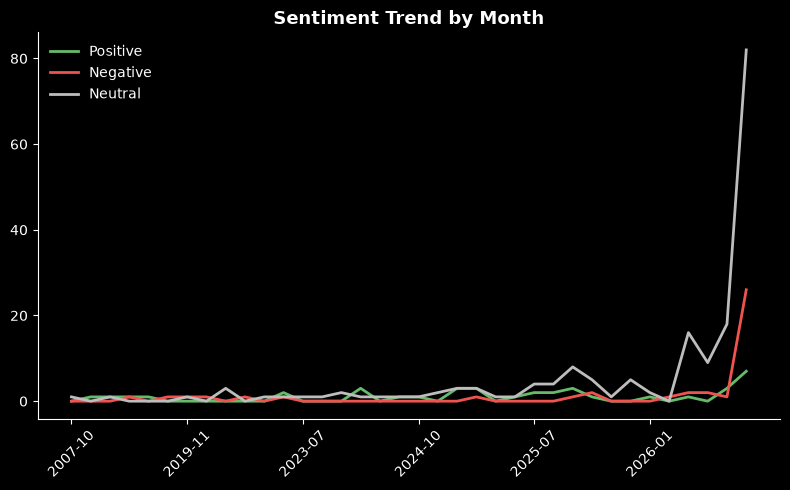

In [10]:
sorted_months = sorted(trends.keys())
pos = [trends[m]["positive"] for m in sorted_months]
neg = [trends[m]["negative"] for m in sorted_months]
neu = [trends[m]["neutral"] for m in sorted_months]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_months, pos, label="Positive", color="#66BB6A", linewidth=2)
ax.plot(sorted_months, neg, label="Negative", color="#EF5350", linewidth=2)
ax.plot(sorted_months, neu, label="Neutral", color="#BDBDBD", linewidth=2)
ax.set_xticks(range(0, len(sorted_months), max(1, len(sorted_months)//6)))
ax.set_xticklabels(sorted_months[::max(1, len(sorted_months)//6)], rotation=45)
ax.legend(frameon=False)
ax.set_title("Sentiment Trend by Month", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
import plotly.express as px
import pandas as pd

# Calculate cumulative totals from the lists already built for the line chart
total_pos = sum(pos)
total_neg = sum(neg)
total_neu = sum(neu)

df_pie = pd.DataFrame({
    "Sentiment": ["Positive", "Neutral", "Negative"],
    "Count": [total_pos, total_neu, total_neg]
})

fig_pie = px.pie(
    df_pie,
    values="Count",
    names="Sentiment",
    hole=0.5,
    color="Sentiment",
    color_discrete_map={"Positive": "#2ECC71", "Neutral": "#95A5A6", "Negative": "#E74C3C"}
)

fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.update_layout(
    title="<b>Overall Sentiment Share</b>",
    margin=dict(l=20, r=20, t=50, b=20),
    showlegend=False,
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)"
)

fig_pie.show()